# 🏢 HR Attrition Analysis

---

| | |
|---|---|
| 🛠️ **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn |
| 📂 **Dataset** | IBM HR Analytics (Kaggle) — 1,470 employees |
| 🎯 **Goal** | Analyze why employees leave and identify key patterns |
| 👤 **Author** | Hema Naga santhoshi |
| 📅 **Date** | March 2026 |

## 📦 Step 1: Import Libraries
Loading all required Python libraries for data analysis and visualization.

In [ ]:
# Install libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset
Loading the IBM HR Analytics dataset containing 1,470 employee records.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [ ]:
import os

# Check the exact filename
path = "/kaggle/input/ibm-hr-analytics-attrition-dataset"
print("Files available:", os.listdir(path))

Files available: ['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [ ]:
# Load the dataset
df = pd.read_csv(f"{path}/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset Loaded!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 🔍 Step 3: Explore the Data
Understanding the structure, shape, and data types of the dataset.

In [ ]:
# Basic info
print("📋 Dataset Info:")
print(df.info())


📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel

## 🧪 Step 4: Check Data Quality
Checking for missing values, duplicates, and target variable distribution.

In [ ]:
print("🔍 Missing Values:")
print(df.isnull().sum())

print(f"\n🔁 Duplicate Rows: {df.duplicated().sum()}")

print(f"\n🎯 Attrition Value Counts:")
print(df['Attrition'].value_counts())

# Attrition Rate
attrition_rate = round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2)
print(f"\n📉 Overall Attrition Rate: {attrition_rate}%")

🔍 Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole    

## 🧹 Step 5: Clean the Data
Removing irrelevant columns and converting target variable to binary format.

In [ ]:
# Checking all column names in dataset
print(df.columns.tolist())


['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']


In [ ]:
# Safely drop only columns that actually exist
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Only drop columns that exist in dataframe
existing_cols = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=existing_cols, inplace=True)

print(f"✅ Dropped columns: {existing_cols}")

# Convert Attrition to binary
df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print("✅ Data Cleaned!")
print(f"New Shape: {df.shape}")

✅ Dropped columns: []
✅ Data Cleaned!
New Shape: (1470, 32)


In [ ]:
print(f"Total Columns: {len(df.columns)}")
print("\nAll Column Names:")
for col in df.columns:
    print(col)

Total Columns: 32

All Column Names:
Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager
Attrition_Flag


## 📊 Step 6: Attrition by Department
Which department has the highest employee turnover?

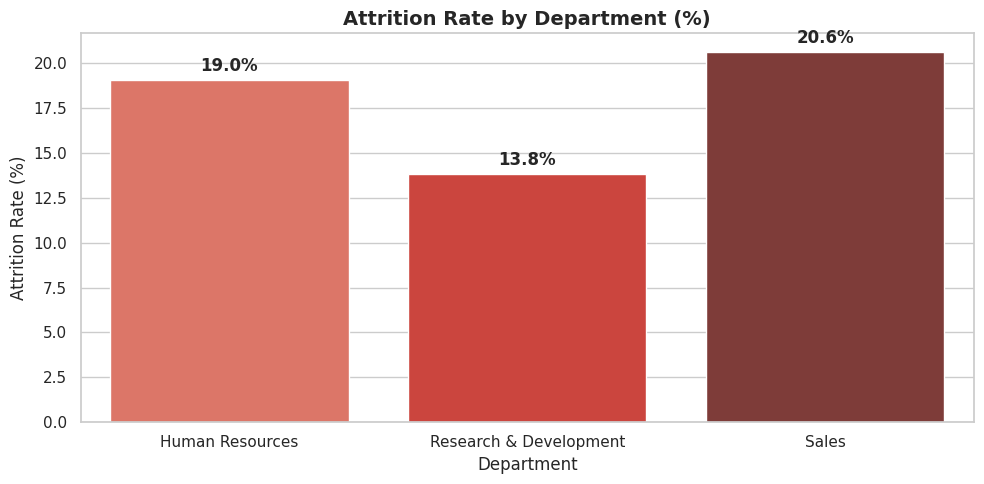

In [ ]:
# Attrition by Department

plt.figure(figsize=(10, 5))
dept_attrition = df.groupby('Department')['Attrition_Flag'].mean() * 100

sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_d')
plt.title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')

for i, v in enumerate(dept_attrition.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 📈 Step 7: Age Distribution by Attrition
Which age group is most likely to leave the company?

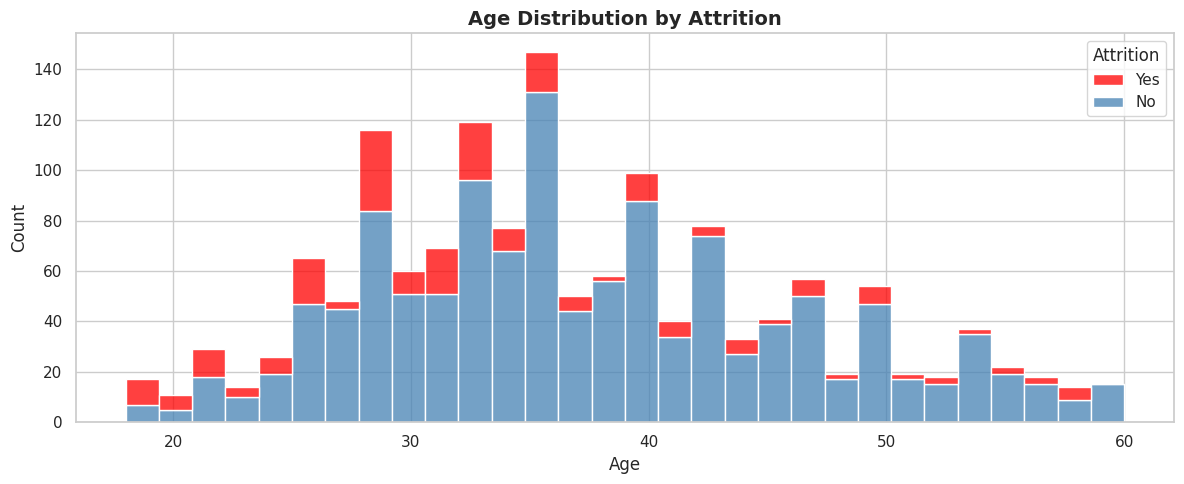

In [ ]:
# Age Distribution

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Age', hue='Attrition',
             multiple='stack', palette={'Yes':'red', 'No':'steelblue'}, bins=30)
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 💰 Step 8: Monthly Income vs Attrition
Does salary influence an employee's decision to leave?

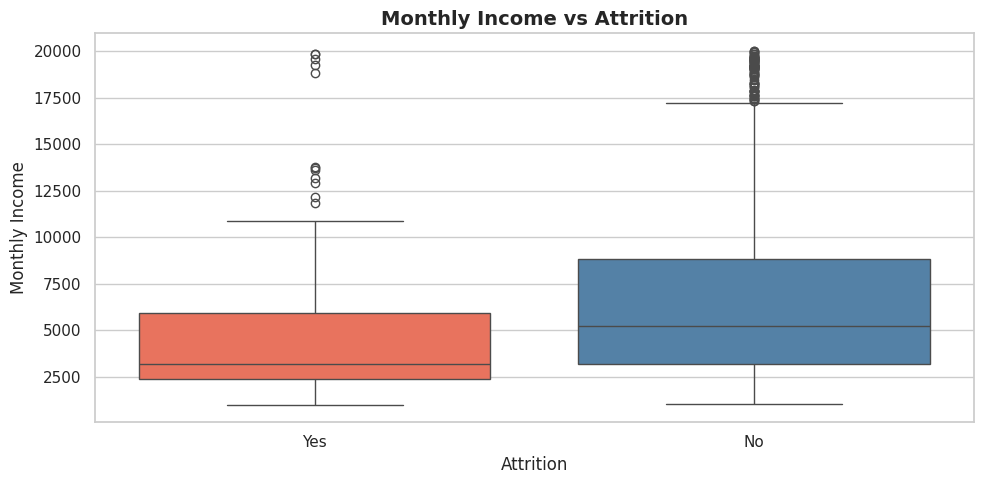

In [ ]:
# Monthly Income vs Attrition

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes':'tomato', 'No':'steelblue'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

## 🌡️ Step 9: Correlation Heatmap
Understanding relationships between all numerical variables.

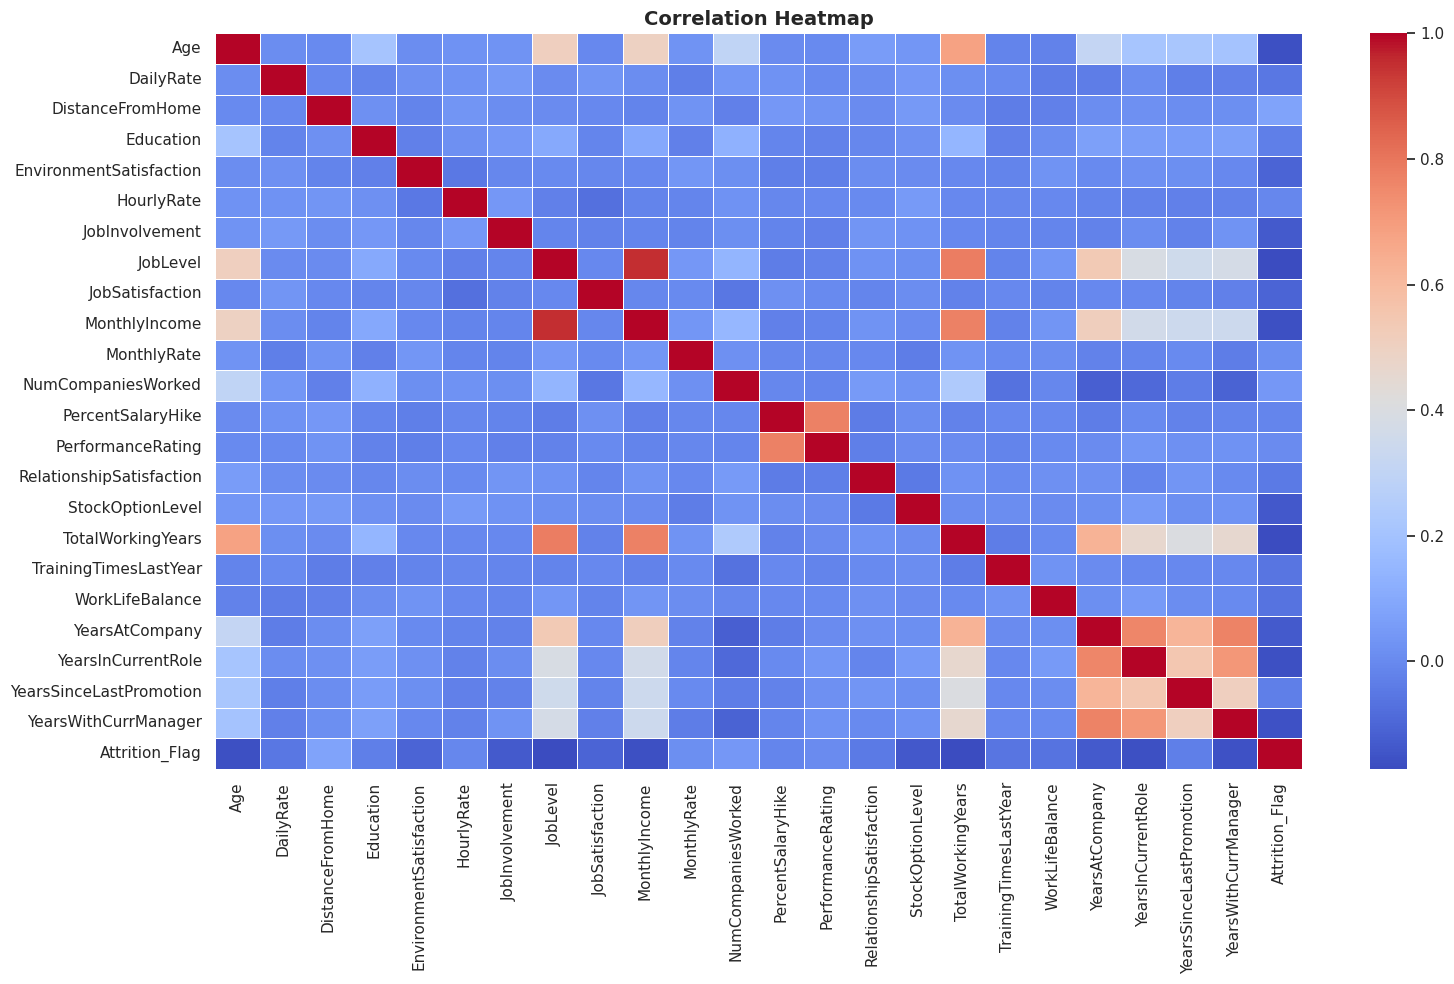

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(16, 10))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm',
            linewidths=0.5, fmt='.1f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 👔 Step 10: Attrition by Job Role
Which specific job roles are at highest risk of attrition?

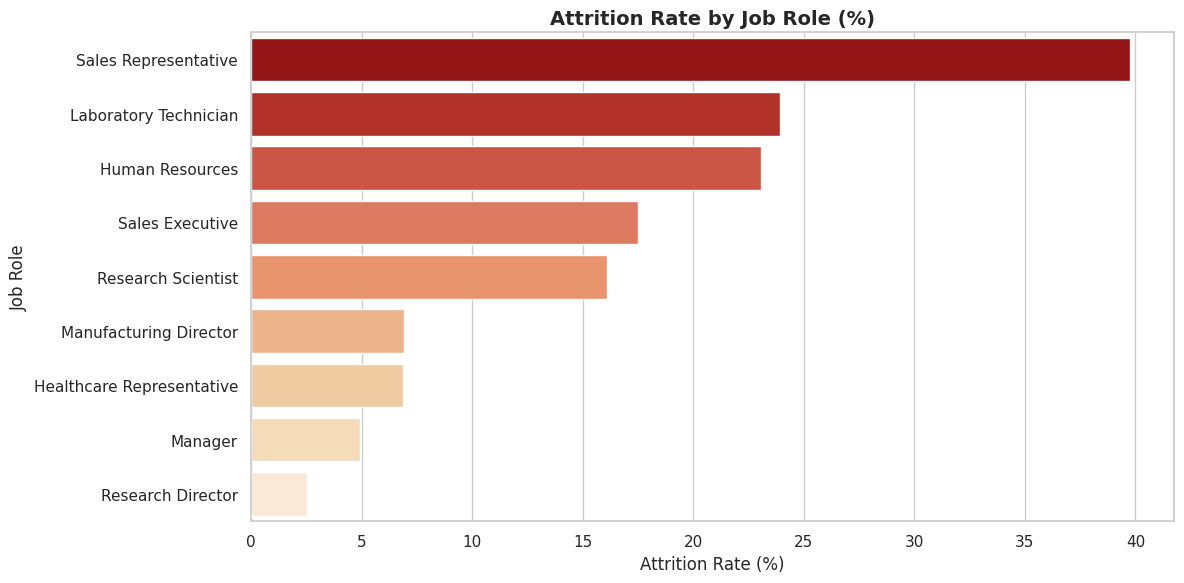

In [ ]:
# Job Role vs Attrition!
plt.figure(figsize=(12, 6))
role_attrition = df.groupby('JobRole')['Attrition_Flag'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False)

sns.barplot(x=role_attrition.values, y=role_attrition.index, palette='OrRd_r')
plt.title('Attrition Rate by Job Role (%)', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

In [ ]:
## 🔍 Key Findings

1. ## Sales Representatives have the highest attrition at ~40%
2. ## Employees aged 26–35 leave the most — career exploration phase
3. ## Lower monthly income strongly linked to attrition
4. ## JobLevel & MonthlyIncome are highly correlated — salary drives retention
5. ## Senior roles (Manager, Research Director) are most stable

## 💡 Business Recommendations

1.## Review and improve compensation for Sales Representatives
2.## Create clear career growth paths for Lab Technicians and Sales roles
3.## Introduce retention bonuses for employees in 26–35 age group
4.## Reduce overtime — it significantly impacts work-life balance
5.## Conduct stay interviews for high-risk roles before they decide to leave

5.0